# California Flight Delays in 2024

## Install Dependency to Import from Kaggle

In [34]:
!pip install opendatasets

In [35]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/hrishitpatil/flight-data-2024/")

Skipping, found downloaded files in "./flight-data-2024" (use force=True to force download)


## Read in `flight_data_2024.csv`

In [36]:
import pandas as pd
df = pd.read_csv("/content/flight-data-2024/flight_data_2024.csv")

/tmp/ipykernel_172/3967702268.py:2: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/flight-data-2024/flight_data_2024.csv")


## Filter dataframe by `California` with 10K sample

In [49]:
df_california = df[df['origin_state_nm'] == "California"].sample(10000)
df_california.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 6391224 to 1488468
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 10000 non-null  int64  
 1   month                10000 non-null  int64  
 2   day_of_month         10000 non-null  int64  
 3   day_of_week          10000 non-null  int64  
 4   fl_date              10000 non-null  object 
 5   op_unique_carrier    10000 non-null  object 
 6   op_carrier_fl_num    10000 non-null  float64
 7   origin               10000 non-null  object 
 8   origin_city_name     10000 non-null  object 
 9   origin_state_nm      10000 non-null  object 
 10  dest                 10000 non-null  object 
 11  dest_city_name       10000 non-null  object 
 12  dest_state_nm        10000 non-null  object 
 13  crs_dep_time         10000 non-null  int64  
 14  dep_time             10000 non-null  float64
 15  dep_delay            10000 non-nu

In [50]:
df_california

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,dep_hour
6391224,2024,11,25,1,2024-11-25,UA,512.0,SFO,"San Francisco, CA",California,...,225.0,195.0,174.0,1635.0,0,0,0,0,0,0
4654874,2024,8,28,3,2024-08-28,WN,3948.0,LAX,"Los Angeles, CA",California,...,80.0,66.0,55.0,373.0,0,0,0,0,0,15
3207221,2024,6,18,2,2024-06-18,OO,4077.0,LAX,"Los Angeles, CA",California,...,82.0,78.0,61.0,370.0,0,0,0,0,0,16
2151497,2024,4,26,5,2024-04-26,DL,912.0,ONT,"Ontario, CA",California,...,244.0,235.0,212.0,1900.0,0,0,0,0,0,6
783977,2024,2,14,3,2024-02-14,OO,3977.0,LAX,"Los Angeles, CA",California,...,86.0,87.0,68.0,337.0,0,0,0,0,0,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5307802,2024,10,1,2,2024-10-01,OO,4087.0,LAX,"Los Angeles, CA",California,...,56.0,55.0,31.0,109.0,0,0,0,0,0,16
5969000,2024,11,3,7,2024-11-03,WN,713.0,SMF,"Sacramento, CA",California,...,195.0,198.0,176.0,1442.0,0,0,0,0,0,5
2580342,2024,5,18,6,2024-05-18,DL,2614.0,LAX,"Los Angeles, CA",California,...,85.0,78.0,54.0,337.0,0,0,0,0,0,5
1896247,2024,4,13,6,2024-04-13,AS,530.0,SAN,"San Diego, CA",California,...,178.0,187.0,134.0,1164.0,0,0,0,0,0,11


In [51]:
#Show amount of NaN values for each column
df.isna().sum().sort_values(ascending=False)

,0
op_carrier_fl_num,1
month,0
year,0
day_of_month,0
day_of_week,0
fl_date,0
op_unique_carrier,0
origin,0
origin_city_name,0
origin_state_nm,0


## Convert `op_unique_carrier` (airline code) to full Airline name and add to new column

In [52]:
# Translate Carrier Code to Airline
def airline(x):
  if x == "AA":
    return "American Airlines"
  elif x == "AS":
    return "Alaska Airlines"
  elif x == "B6":
    return "JetBlue Airways"
  elif x == "DL":
    return "Delta Airlines"
  elif x == "F9":
    return "Frontier Airlines"
  elif x == "G4":
    return "Allegiant Air"
  elif x == "HA":
    return "Hawaiian Airlines"
  elif x == "MQ":
    return "Envoy Air"
  elif x == "NK":
    return "Spirit Airlines"
  elif x == "OO":
    return "SkyWest Airlines"
  elif x == "UA":
    return "United Airlines"
  elif x == "WN":
    return "Southwest Airlines"

df_california["Airline"] = df_california['op_unique_carrier'].apply(airline)


In [53]:
df_california["op_unique_carrier"].unique()

array(['UA', 'WN', 'OO', 'DL', 'AA', 'MQ', 'HA', 'AS', 'G4', 'NK', 'B6',
       'F9'], dtype=object)

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

## Average Delay by Departure Hour (categorical bar plot)

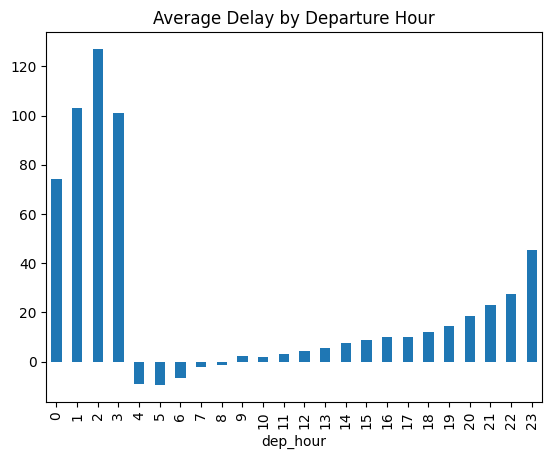

In [55]:
df['dep_hour'] = (df['dep_time'] // 100).astype(int)
df.loc[df["dep_hour"] == 24, "dep_hour"] = 0
avg_delay = df.groupby("dep_hour")["arr_delay"].mean()
avg_delay.plot(kind="bar")
plt.title("Average Delay by Departure Hour")
plt.show()

## Relationship between Distance and Air Time (small-multiples relplot)

In [56]:
def delay_time(x):
    if x < 0:
        return "Early"
    elif x==0:
        return "On time"
    elif 0< x < 15:
        return "Slightly Late (<15mins)"
    elif 15<x<60:
        return "Late (<60mins)"
    else:
        return "Very late (>60 mins)"
df_california["Late_status"]=df_california["arr_delay"].apply(delay_time)

Text(0.5, 1.0, 'Relationship between distance and air time')

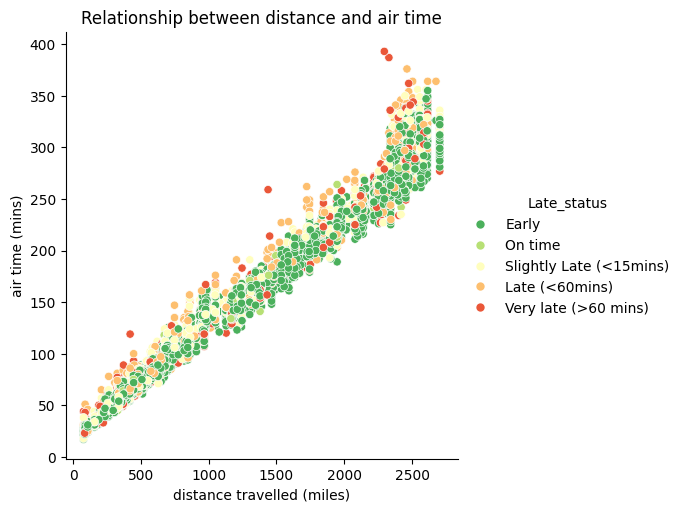

In [57]:
hue_order = ["Early", "On time","Slightly Late (<15mins)", "Late (<60mins)", "Very late (>60 mins)"]
sns.relplot(data=df_california,
            x="distance",
            y="air_time",
            hue="Late_status",
            hue_order=hue_order,
            palette="RdYlGn_r")
plt.xlabel("distance travelled (miles)")
plt.ylabel("air time (mins)")
plt.title("Relationship between distance and air time")

## Calculate Average Delay by Airline

Calculate the average arrival delay for each airline in the `df_california` DataFrame.


In [58]:
avg_delay_by_airline = df_california.groupby('Airline')['arr_delay'].mean()
avg_delay_by_airline

,arr_delay
Airline,
Alaska Airlines,2.921875
Allegiant Air,10.433333
American Airlines,11.517241
Delta Airlines,4.968222
Envoy Air,-0.378378
Frontier Airlines,22.431624
Hawaiian Airlines,9.174757
JetBlue Airways,7.366197
SkyWest Airlines,7.511262


## Plot Average Delay by Airline




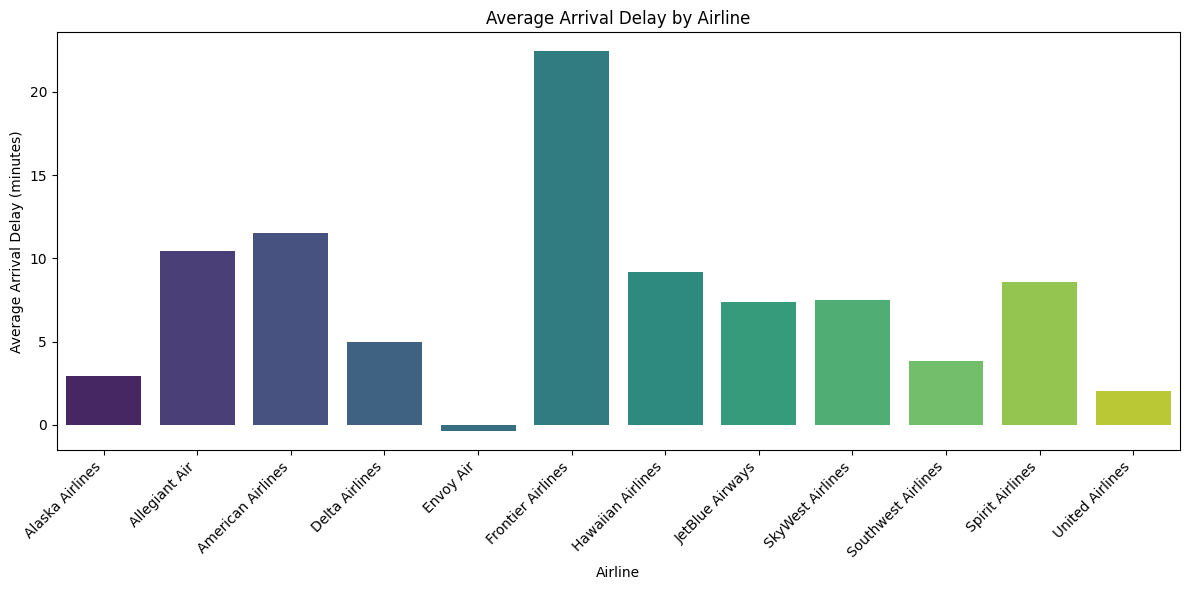

In [59]:
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_delay_by_airline.index, y=avg_delay_by_airline.values, hue=avg_delay_by_airline.index, palette='viridis', legend=False)
plt.title('Average Arrival Delay by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Arrival Delay (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

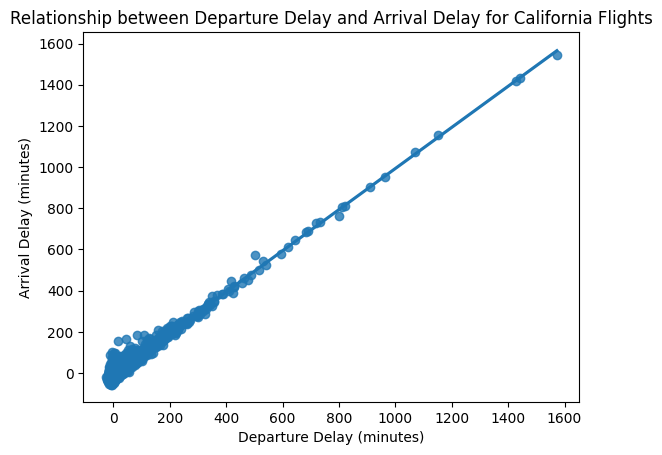

In [60]:
sns.regplot(data=df_california, x='dep_delay', y='arr_delay')
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Arrival Delay (minutes)')
plt.title('Relationship between Departure Delay and Arrival Delay for California Flights')
plt.show()